# CleanOps AI Scoring - Report Charts Defense Notebook

This notebook reproduces every benchmark chart used in the AI-scoring report from the source CSV/JSON files. It is intended for project defense: when a reviewer asks where a number or chart comes from, run the relevant section and show the recomputed values.

## Source Files

- Cleaning benchmark CSV: `outputs/reports/scoring_pilot_assets_rerun/pilot_benchmark_dataset_enriched.csv`
- Cleaning benchmark summary: `outputs/reports/scoring_pilot_assets_rerun/pilot_benchmark_summary.json`
- PPE benchmark summary: `outputs/reports/ppe_pilot_assets_rerun/ppe_pilot_benchmark_summary.json`

The notebook does not use pre-rendered chart PNGs as input. It recomputes the metrics and then renders the charts again.

In [1]:
from __future__ import annotations

import csv
import json
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name.lower() == "notebooks" else cwd

SCORING_CSV = ROOT / "outputs/reports/scoring_pilot_assets_rerun/pilot_benchmark_dataset_enriched.csv"
SCORING_SUMMARY_JSON = ROOT / "outputs/reports/scoring_pilot_assets_rerun/pilot_benchmark_summary.json"
PPE_SUMMARY_JSON = ROOT / "outputs/reports/ppe_pilot_assets_rerun/ppe_pilot_benchmark_summary.json"
CHART_DIR = ROOT / "outputs/reports/notebook_charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

for path in [SCORING_CSV, SCORING_SUMMARY_JSON, PPE_SUMMARY_JSON]:
    if not path.exists():
        raise FileNotFoundError(path)

def load_csv_rows(path: Path) -> list[dict[str, str]]:
    if pd is not None:
        return pd.read_csv(path).fillna("").astype(str).to_dict("records")
    with path.open("r", encoding="utf-8-sig", newline="") as handle:
        return list(csv.DictReader(handle))

def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))

scoring_rows = load_csv_rows(SCORING_CSV)
scoring_summary = load_json(SCORING_SUMMARY_JSON)
ppe_summary = load_json(PPE_SUMMARY_JSON)

GOOD = "#2e7d32"
GOOD_ALT = "#1565c0"
RISK = "#c62828"
WARNING = "#f9a825"
NEUTRAL = "#9e9e9e"
GRID = "#d9dde3"
TEXT = "#1f2937"
BACKGROUND = "white"

plt.rcParams.update({
    "figure.facecolor": BACKGROUND,
    "axes.facecolor": BACKGROUND,
    "axes.edgecolor": "#c7cdd6",
    "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "grid.color": GRID,
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "axes.grid": True,
    "axes.axisbelow": True,
    "font.size": 11,
})

def save_chart(fig: plt.Figure, filename: str) -> Path:
    path = CHART_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor=BACKGROUND)
    return path

def label_percent_bars(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 1.2, f"{height:.1f}%", ha="center", va="bottom", color=TEXT, fontsize=10)

print(f"Project root: {ROOT}")
print(f"Loaded scoring rows: {len(scoring_rows)}")
print(f"Notebook charts will be written to: {CHART_DIR}")

Project root: e:\capstone\cleanops-server-side\cleanops-ai-scoring
Loaded scoring rows: 19
Notebook charts will be written to: e:\capstone\cleanops-server-side\cleanops-ai-scoring\outputs\reports\notebook_charts


## Chart 1 - Scoring Outcome Breakdown

Purpose: show mutually exclusive benchmark outcomes. These categories are designed to sum to 100%, unlike operational KPIs such as Pending Review Rate.

In [2]:
VALID_VERDICTS = {"PASS", "PENDING", "FAIL"}

def normalize_verdict(value: str) -> str:
    return str(value or "").strip().upper()

def is_valid_scoring_row(row: dict[str, str]) -> bool:
    return normalize_verdict(row.get("expected_verdict")) in VALID_VERDICTS and normalize_verdict(row.get("predicted_verdict")) in VALID_VERDICTS

def classify_scoring_outcome(expected: str, predicted: str) -> str:
    expected = normalize_verdict(expected)
    predicted = normalize_verdict(predicted)
    if expected == predicted:
        return "Correct"
    if predicted == "PASS" and expected != "PASS":
        return "False Pass"
    if predicted == "FAIL" and expected == "PASS":
        return "False Fail"
    return "Other Mismatch"

valid_scoring_rows = [row for row in scoring_rows if is_valid_scoring_row(row)]
excluded_scoring_rows = [row for row in scoring_rows if not is_valid_scoring_row(row)]
outcome_counts = Counter(classify_scoring_outcome(row["expected_verdict"], row["predicted_verdict"]) for row in valid_scoring_rows)

labels = ["Correct", "False Pass", "False Fail", "Other Mismatch"]
counts = [outcome_counts[label] for label in labels]
total_valid = len(valid_scoring_rows)
percentages = [count / total_valid * 100 for count in counts]

assert total_valid == 18, total_valid
assert counts == [8, 2, 2, 6], counts
assert round(sum(percentages), 6) == 100.0

print("Valid samples:", total_valid)
print("Excluded samples:", [row.get("image_id") for row in excluded_scoring_rows])
print(dict(zip(labels, counts)))
print("Percent sum:", sum(percentages))

Valid samples: 18
Excluded samples: ['scoring_18']
{'Correct': 8, 'False Pass': 2, 'False Fail': 2, 'Other Mismatch': 6}
Percent sum: 100.0


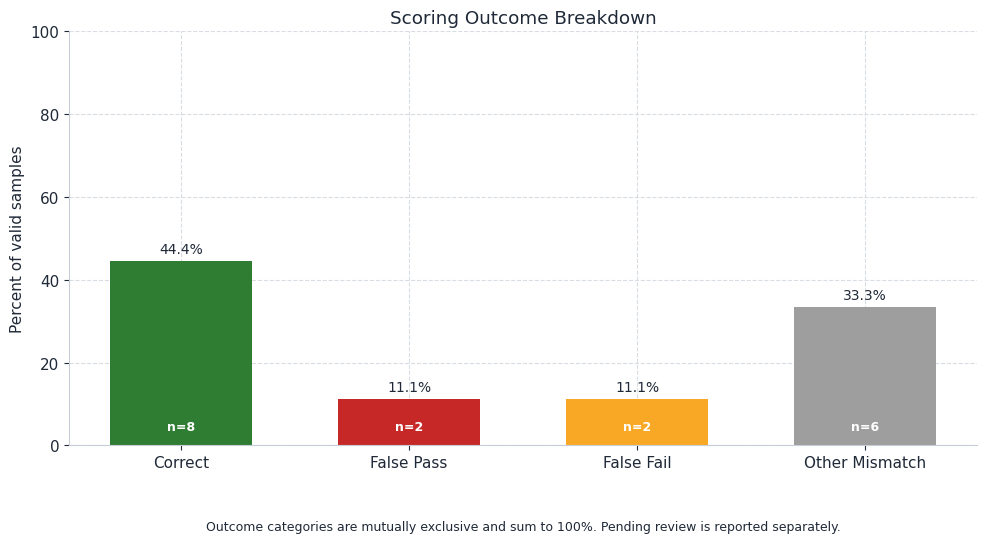

e:\capstone\cleanops-server-side\cleanops-ai-scoring\outputs\reports\notebook_charts\scoring_outcome_breakdown.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 5.6))
bars = ax.bar(labels, percentages, color=[GOOD, RISK, WARNING, NEUTRAL], width=0.62)
ax.set_ylim(0, 100)
ax.set_ylabel("Percent of valid samples")
ax.set_title("Scoring Outcome Breakdown")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
label_percent_bars(ax, bars)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, 3, f"n={count}", ha="center", va="bottom", color="white", fontsize=9, fontweight="bold")
ax.text(0.5, -0.18, "Outcome categories are mutually exclusive and sum to 100%. Pending review is reported separately.", transform=ax.transAxes, ha="center", va="top", color=TEXT, fontsize=9)
path = save_chart(fig, "scoring_outcome_breakdown.png")
if matplotlib.get_backend().lower() != "agg":
    plt.show()
print(path)

**Defense notes**

- Denominator is 18 valid samples; `scoring_18` is excluded because the image fetch failed and no predicted verdict exists.
- Correct, False Pass, False Fail, and Other Mismatch are mutually exclusive, so they sum to 100%.
- Pending Review Rate is not part of this stacked outcome breakdown; it is an operational workload KPI.

## Chart 2 - Scoring Prediction Distribution

Purpose: show how conservative the scoring service is by counting predicted PASS, PENDING, and FAIL verdicts.

In [4]:
predicted_counts = scoring_summary["counts"]["predicted"]
prediction_labels = ["PASS", "PENDING", "FAIL"]
prediction_values = [predicted_counts.get(label, 0) for label in prediction_labels]

assert prediction_values == [6, 10, 2], prediction_values
print(dict(zip(prediction_labels, prediction_values)))

{'PASS': 6, 'PENDING': 10, 'FAIL': 2}


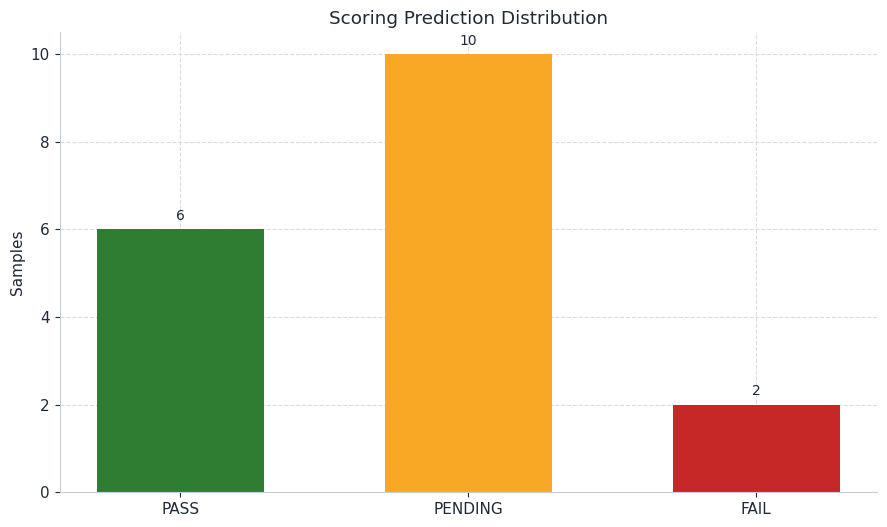

e:\capstone\cleanops-server-side\cleanops-ai-scoring\outputs\reports\notebook_charts\scoring_prediction_distribution.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5.4))
bars = ax.bar(prediction_labels, prediction_values, color=[GOOD, WARNING, RISK], width=0.58)
ax.set_ylabel("Samples")
ax.set_title("Scoring Prediction Distribution")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.15, str(int(height)), ha="center", va="bottom", color=TEXT, fontsize=10)
path = save_chart(fig, "scoring_prediction_distribution.png")
if matplotlib.get_backend().lower() != "agg":
    plt.show()
print(path)

**Defense notes**

- The model predicts PENDING for 10 out of 18 valid samples.
- This supports the report interpretation that the current scoring model is conservative.
- Conservative behavior reduces automatic false approval risk, but increases supervisor review workload.

## Chart 3 - Environment Outcome Breakdown

Purpose: compare outcome composition inside each environment. Every environment bar is normalized to 100%, so it explains proportions, not raw sample volume.

In [6]:
environment_order = ["LOBBY_CORRIDOR", "RESTROOM", "OUTDOOR_LANDSCAPE"]
environment_totals = Counter(row["environment_key"] for row in valid_scoring_rows)
environment_outcomes: dict[str, Counter[str]] = defaultdict(Counter)

for row in valid_scoring_rows:
    env = row["environment_key"]
    category = classify_scoring_outcome(row["expected_verdict"], row["predicted_verdict"])
    environment_outcomes[env][category] += 1

for env in environment_order:
    counts_for_env = [environment_outcomes[env][label] for label in labels]
    print(env, "total=", environment_totals[env], dict(zip(labels, counts_for_env)))

assert [environment_totals[env] for env in environment_order] == [13, 3, 2]
assert [environment_outcomes["LOBBY_CORRIDOR"][label] for label in labels] == [7, 1, 2, 3]
assert [environment_outcomes["RESTROOM"][label] for label in labels] == [0, 1, 0, 2]
assert [environment_outcomes["OUTDOOR_LANDSCAPE"][label] for label in labels] == [1, 0, 0, 1]

LOBBY_CORRIDOR total= 13 {'Correct': 7, 'False Pass': 1, 'False Fail': 2, 'Other Mismatch': 3}
RESTROOM total= 3 {'Correct': 0, 'False Pass': 1, 'False Fail': 0, 'Other Mismatch': 2}
OUTDOOR_LANDSCAPE total= 2 {'Correct': 1, 'False Pass': 0, 'False Fail': 0, 'Other Mismatch': 1}


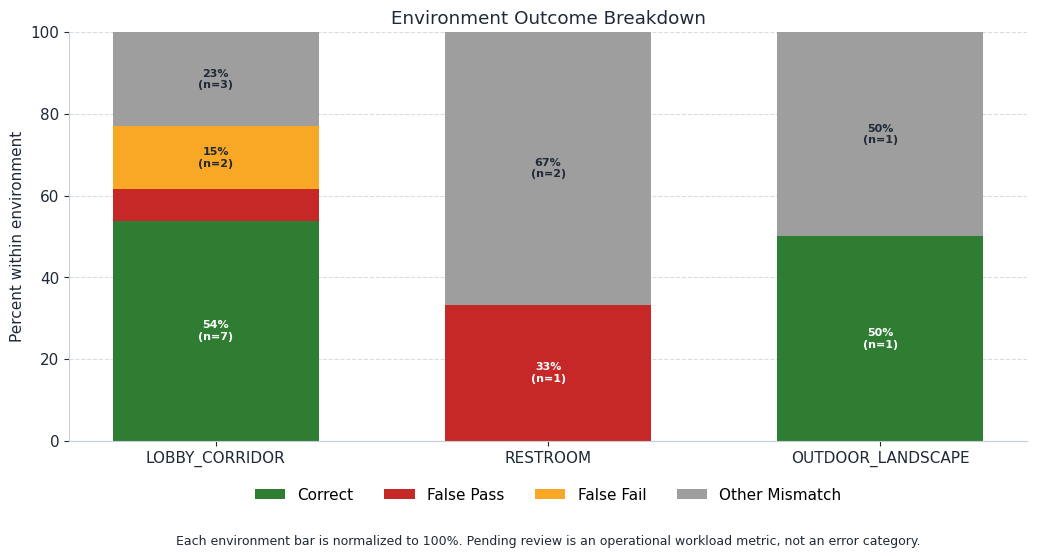

e:\capstone\cleanops-server-side\cleanops-ai-scoring\outputs\reports\notebook_charts\environment_outcome_breakdown.png


In [7]:
x = np.arange(len(environment_order))
fig, ax = plt.subplots(figsize=(10.5, 5.8))
bottoms = np.zeros(len(environment_order))
category_colors = [GOOD, RISK, WARNING, NEUTRAL]

for category, color in zip(labels, category_colors):
    values = []
    for env in environment_order:
        total = environment_totals[env]
        values.append(environment_outcomes[env][category] / total * 100 if total else 0)
    bars = ax.bar(x, values, bottom=bottoms, label=category, color=color, width=0.62)
    for bar, value, bottom, env in zip(bars, values, bottoms, environment_order):
        count = environment_outcomes[env][category]
        if value >= 9:
            ax.text(bar.get_x() + bar.get_width() / 2, bottom + value / 2, f"{value:.0f}%\n(n={count})", ha="center", va="center", color="white" if category in {"Correct", "False Pass"} else TEXT, fontsize=8, fontweight="bold")
    bottoms += np.array(values)

ax.set_xticks(x)
ax.set_xticklabels(environment_order)
ax.set_ylim(0, 100)
ax.set_ylabel("Percent within environment")
ax.set_title("Environment Outcome Breakdown")
ax.legend(frameon=False, ncols=4, loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.text(0.5, -0.23, "Each environment bar is normalized to 100%. Pending review is an operational workload metric, not an error category.", transform=ax.transAxes, ha="center", va="top", color=TEXT, fontsize=9)
path = save_chart(fig, "environment_outcome_breakdown.png")
if matplotlib.get_backend().lower() != "agg":
    plt.show()
print(path)

**Defense notes**

- Each environment is normalized independently to 100%.
- `LOBBY_CORRIDOR` has 13 valid samples, while `RESTROOM` and `OUTDOOR_LANDSCAPE` are much smaller.
- The chart should be read as outcome composition, not as absolute deployment performance.

## Chart 4 - PPE Metrics Overview

Purpose: summarize PPE pilot quality with two percentage metrics and one items-per-case metric.

In [8]:
ppe_metric_labels = ["Status Accuracy", "Missing Recall", "False Missing Items per Case"]
ppe_metric_values = [
    ppe_summary["ppe_status_accuracy"] * 100,
    ppe_summary["missing_item_recall"] * 100,
    ppe_summary["false_missing_rate"],
]

assert ppe_metric_values == [25.0, 80.0, 1.5], ppe_metric_values
print(dict(zip(ppe_metric_labels, ppe_metric_values)))
print("False missing items:", ppe_summary["counts"]["false_missing_items"])
print("PPE cases:", ppe_summary["total_samples"])
print("Items per case:", ppe_summary["counts"]["false_missing_items"] / ppe_summary["total_samples"])

{'Status Accuracy': 25.0, 'Missing Recall': 80.0, 'False Missing Items per Case': 1.5}
False missing items: 36
PPE cases: 24
Items per case: 1.5


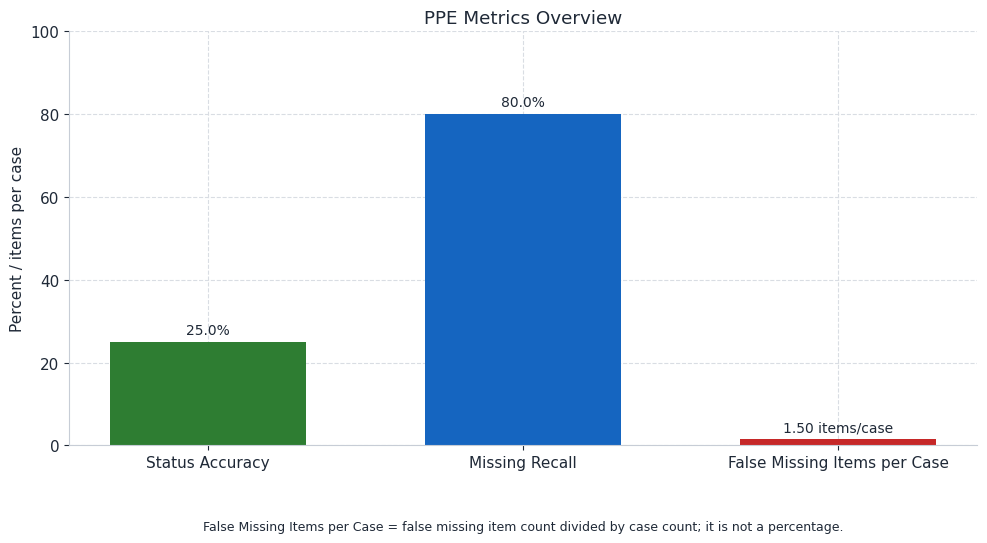

e:\capstone\cleanops-server-side\cleanops-ai-scoring\outputs\reports\notebook_charts\ppe_metrics_overview.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5.6))
bars = ax.bar(ppe_metric_labels, ppe_metric_values, color=[GOOD, GOOD_ALT, RISK], width=0.62)
ax.set_title("PPE Metrics Overview")
ax.set_ylabel("Percent / items per case")
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for idx, bar in enumerate(bars):
    height = bar.get_height()
    label = f"{height:.1f}%" if idx < 2 else f"{height:.2f} items/case"
    ax.text(bar.get_x() + bar.get_width() / 2, height + 1.2, label, ha="center", va="bottom", color=TEXT, fontsize=10)
ax.text(0.5, -0.18, "False Missing Items per Case = false missing item count divided by case count; it is not a percentage.", transform=ax.transAxes, ha="center", va="top", color=TEXT, fontsize=9)
path = save_chart(fig, "ppe_metrics_overview.png")
if matplotlib.get_backend().lower() != "agg":
    plt.show()
print(path)

**Defense notes**

- Status accuracy is `6/24 = 25%`.
- Missing-item recall is `4/5 = 80%`.
- False Missing Items per Case is `36/24 = 1.50 items/case`; it is not `150%`.

## Chart 5 - PPE Confusion Matrix

Purpose: show PASS/FAIL status-level confusion for PPE compliance.

In [10]:
ppe_confusion = ppe_summary["confusion_matrix"]
ppe_matrix = np.array([
    [ppe_confusion["PASS"]["PASS"], ppe_confusion["PASS"]["FAIL"]],
    [ppe_confusion["FAIL"]["PASS"], ppe_confusion["FAIL"]["FAIL"]],
])

assert ppe_matrix.tolist() == [[1, 18], [0, 5]], ppe_matrix.tolist()
print(ppe_matrix)

[[ 1 18]
 [ 0  5]]


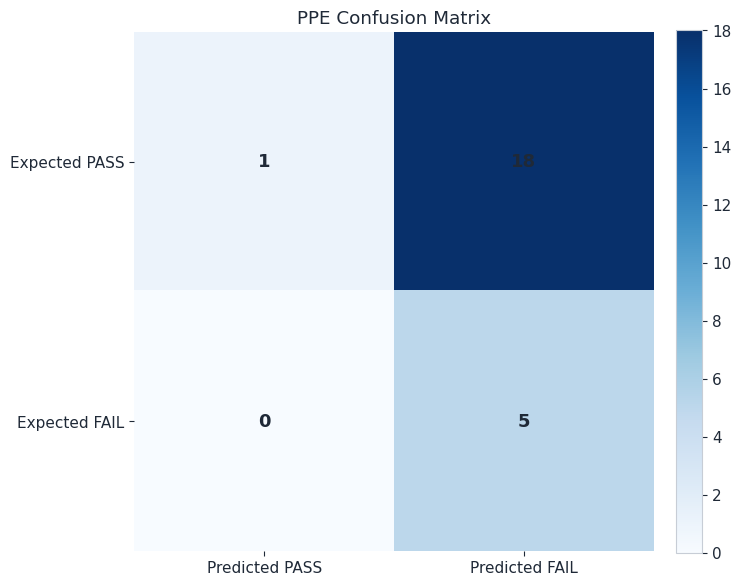

e:\capstone\cleanops-server-side\cleanops-ai-scoring\outputs\reports\notebook_charts\ppe_confusion_matrix.png


In [11]:
row_labels = ["Expected PASS", "Expected FAIL"]
col_labels = ["Predicted PASS", "Predicted FAIL"]

fig, ax = plt.subplots(figsize=(7.2, 6.2))
im = ax.imshow(ppe_matrix, cmap="Blues")
ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))
ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)
ax.set_title("PPE Confusion Matrix")
for i in range(ppe_matrix.shape[0]):
    for j in range(ppe_matrix.shape[1]):
        ax.text(j, i, str(ppe_matrix[i, j]), ha="center", va="center", color=TEXT, fontsize=13, fontweight="bold")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
path = save_chart(fig, "ppe_confusion_matrix.png")
if matplotlib.get_backend().lower() != "agg":
    plt.show()
print(path)

**Defense notes**

- The PPE model is safety-first: it tends to warn rather than pass uncertain cases.
- This creates many false FAIL predictions for expected PASS cases.
- Therefore, the report positions PPE as screening/review support, not standalone compliance approval.

## Final Defense Summary

- All charts are reproduced from benchmark CSV/JSON files, not manually drawn images.
- Cleaning denominator is 18 valid samples because `scoring_18` has no valid prediction after image fetch failure.
- Pending Review Rate is a workload metric, not an outcome class, so it is not added into the 100% outcome chart.
- Environment bars are normalized separately because each environment has a different sample count.
- PPE `False Missing Items per Case = 1.50` means 36 falsely missing PPE items across 24 cases; it is not a percentage.